In [ ]:
# ENSEMBLE CREDIT RISK ASSESSMENT: ML + ACO + ANFIS + QP BENCHMARK
#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
#from imblearn.over_sampling import SMOTE
import warnings
from sklearn.exceptions import ConvergenceWarning
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             precision_recall_curve)

In [ ]:
# [Block 1] Data Ingestion & Cryptographic Splitting


print("--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---")

# 1. Ingestion
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data

# 2. Target Variable Topological Mapping
y = data.target.map({'good': 0, 'bad': 1}).values.astype(int)

# 3. Stratified Bifurcation
X_train, X_test, y_train_array, y_test_array = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42   # Deterministic seed for reproducible matrix geometries
)

print(f"Data securely partitioned. Train: {X_train.shape}, Test: {X_test.shape}")

--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---
Data securely partitioned. Train: (800, 20), Test: (200, 20)


In [ ]:
# [Block 2] OOF Generation via Nested CV & Mixed-Data Synthesis

print("\n--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---")

# 1. DEFINE COLUMN TOPOLOGIES
numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
cat_indices = list(range(len(numerical_cols), len(numerical_cols) + len(categorical_cols)))

# 2. PREPROCESSING STAGE 1 (SPATIAL CONDITIONING)
prep_stage_1 = ColumnTransformer(transformers=[
    ('num', RobustScaler(), numerical_cols),
    ('cat', 'passthrough', categorical_cols)
])

# 3. SYNTHESIS STAGE (SMOTENC)
smote_nc = SMOTENC(categorical_features=cat_indices, k_neighbors=5, random_state=42)

# 4. PREPROCESSING STAGE 2 (IDENTITY CAST & ORTHOGONAL EXPANSION)
prep_stage_2 = ColumnTransformer(transformers=[
    ('num_pass', StandardScaler(with_mean=False, with_std=False), list(range(len(numerical_cols)))),
    ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), cat_indices)
])

# 5. CORE ESTIMATORS & PROBABILITY CALIBRATION
rf_base = RandomForestClassifier(random_state=42)
rf_calibrated = CalibratedClassifierCV(rf_base, method='isotonic', cv=6)

svm_base = SVC(kernel='rbf', random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_base, method='sigmoid', cv=6)

mlp_base = MLPClassifier(
    solver='adam', max_iter=2000, early_stopping=True, n_iter_no_change=18, random_state=42
)
mlp_calibrated = CalibratedClassifierCV(mlp_base, method='sigmoid', cv=6)

# 6. ASSEMBLE THE MASTER PIPELINES (IMBLEARN CONTRACT)
base_models = {
    'Random_Forest': ImbPipeline([
        ('prep1', clone(prep_stage_1)), ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)), ('clf', rf_calibrated)
    ]),
    'SVM': ImbPipeline([
        ('prep1', clone(prep_stage_1)), ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)), ('clf', svm_calibrated)
    ]),
    'MLP': ImbPipeline([
        ('prep1', clone(prep_stage_1)), ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)), ('clf', mlp_calibrated)
    ])
}

# 7. HPO SEARCH MANIFOLDS (PRIORS)
param_distributions = {
    'Random_Forest': {
        'clf__estimator__n_estimators': randint(100, 400),
        # Strict bound: N_train=896 means max binary depth is ~log2(896)=9.8.
        # Range [4, 12] forces the constraint to actually bind.
        'clf__estimator__max_depth': randint(4, 12),
        # Structural Risk Minimization: Floor of 5 guarantees terminal nodes
        # compute empirical probabilities, preventing n=1 Dirac-delta memorization.
        'clf__estimator__min_samples_leaf': randint(5, 15),
        'clf__estimator__max_features': uniform(0.1, 0.5)
    },
    'SVM': {
        # loguniform ensures 10^-3 to 10^-2 gets the same search budget as 10^1 to 10^2
        'clf__estimator__C': loguniform(1e-3, 1e2),
        'clf__estimator__gamma': loguniform(1e-4, 1e0)
    },
    'MLP': {
        'clf__estimator__alpha': loguniform(1e-5, 1e-1),
        'clf__estimator__learning_rate_init': loguniform(5e-4, 1e-2),
        'clf__estimator__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32)]
    }
}

# 8. NESTED CROSS-VALIDATION (BI-LEVEL OPTIMIZATION)
K       = 6
skf     = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
N_train = X_train.shape[0]
oof_P_train = np.zeros((N_train, len(base_models)))

tuned_base_models = {}
warnings.filterwarnings("ignore", category=ConvergenceWarning)

for i, (name, model_pipeline) in enumerate(base_models.items()):
    print(f"\nInitiating Stochastic HPO & OOF Generation for {name}...")
    oof_preds = np.zeros(N_train)

    # Layer 4: The HPO Engine
    search = RandomizedSearchCV(
        estimator=model_pipeline,
        param_distributions=param_distributions[name],
        n_iter=18,
        cv=6,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42,
        verbose=2  # Prevents silent execution during extreme computational loads
    )

    # Layer 5: Outer CV Loop
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_array)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train_array[train_idx]
        X_fold_val   = X_train.iloc[val_idx]

        # Fits HPO, applies SMOTE, Calibrates, and trains Core Estimator on inner data
        search.fit(X_fold_train, y_fold_train)

        # Predicts on untouched outer validation data (SMOTE is bypassed here)
        oof_preds[val_idx] = search.predict_proba(X_fold_val)[:, 1]

    oof_P_train[:, i] = oof_preds

    # Final Deployment Retune: Lock in optimal parameters on the full 100% training mass
    print(f"  Retuning {name} on 100% Training Data...")
    final_search = RandomizedSearchCV(
        estimator=model_pipeline,
        param_distributions=param_distributions[name],
        n_iter=18, cv=6, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    final_search.fit(X_train, y_train_array)

    tuned_base_models[name] = final_search.best_estimator_
    print(f"  {name:20s} - Final OOF ROC-AUC: {roc_auc_score(y_train_array, oof_preds):.4f}")

base_models = tuned_base_models

# 9. OOF BIFURCATION
P_opt, P_calib, y_opt, y_calib = train_test_split(
    oof_P_train, y_train_array,
    test_size=0.25, stratify=y_train_array, random_state=42
)
y_opt_float = y_opt.astype(float)


--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---

Initiating Stochastic HPO & OOF Generation for Random_Forest...
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
  Retuning Random_Forest on 100% Training Data...
  Random_Forest        - Final OOF ROC-AUC: 0.7755

Initiating Stochastic HPO & OOF Generation for SVM...
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates, totalling 108 fits
Fitting 6 folds for each of 18 candidates

In [ ]:
# [Block 3] Mathematical Optimization (Convex QP Benchmark)

print("\n--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---")

# 1. THE LINEAR ALGEBRA DERIVATION (MSE to QP Form)
Q = 2 * P_opt.T @ P_opt
c = -2 * (P_opt.T @ y_opt_float)

def qp_objective(w, Q, c):
    """
    Evaluates the standard QP objective function.
    Because Q is a Gram matrix (P^T P), it is Positive Semi-Definite (PSD).
    This mathematically guarantees that the loss surface is a convex bowl
    with exactly one global minimum.
    """
    return 0.5 * w @ Q @ w + c @ w

# 2. THE TOPOLOGICAL CONSTRAINTS (The Probability Simplex)
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

bounds      = tuple((0.0, 1.0) for _ in range(P_opt.shape[1]))

w_init      = np.ones(P_opt.shape[1]) / P_opt.shape[1]

# 3. SLSQP EXECUTION (Sequential Least SQuares Programming)
result = minimize(
    fun=qp_objective,
    x0=w_init,
    args=(Q, c),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9}
)

assert result.success, f"QP Solver encountered a mathematical singularity: {result.message}"

# 4. ACTIVE-SET NUMERICAL SCRUBBING
w_QP  = np.clip(result.x, 0.0, 1.0)
w_QP /= w_QP.sum()

mse_optimal = np.mean((P_opt @ w_QP - y_opt_float) ** 2)
print(f"Optimal QP Weights found. Target Optimization MSE: {mse_optimal:.6f}")


--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---
Optimal QP Weights found. Target Optimization MSE: 0.164596



--- BLOCK 4: ANT COLONY OPTIMIZATION ---
Optimization MSE — QP Optimal: 0.164596 | ACO Swarm: 0.164596
ACO Weights converged. L2 Distance to QP Optimal: 0.000001

Weight Comparison:
  Model                        QP      ACO
  Random_Forest            0.6394   0.6394
  SVM                      0.1241   0.1241
  MLP                      0.2365   0.2365

ACO Sub-optimality gap vs QP: 0.0000%

Initial Swarm MSE: 0.164604 → Final MSE: 0.164596 | Reduction: 0.0%


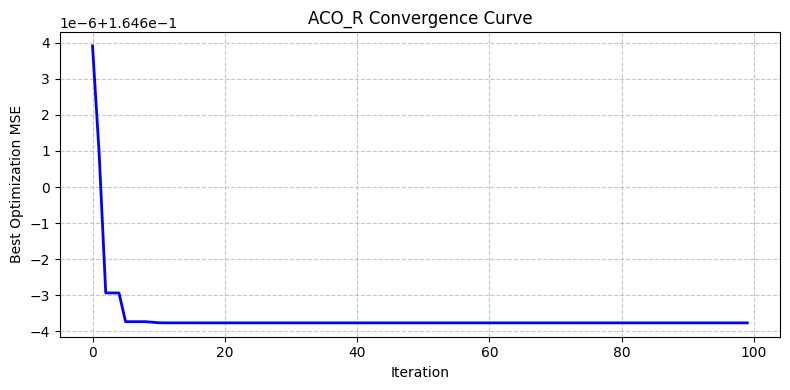

In [ ]:
# [Block 4] Swarm Intelligence (Continuous ACO on Optimization Split)

print("\n--- BLOCK 4: ANT COLONY OPTIMIZATION ---")

# 1. TOPOLOGICAL MAPPING (The Probability Simplex)
def map_to_simplex_softmax(w):
    w_stable = w - np.max(w)
    exp_w    = np.exp(w_stable)
    return exp_w / np.sum(exp_w)

def objective_function(w, P, y):
    w_simplex = map_to_simplex_softmax(w)
    return np.mean((P @ w_simplex - y) ** 2)

def run_acor(P, y, num_models,
             n_ants=40, archive_size=20, iterations=100,
             q=0.1, xi=0.85, seed=42):

    rng     = np.random.default_rng(seed)

    archive = rng.standard_normal((archive_size, num_models))
    scores  = np.array([objective_function(w, P, y) for w in archive])

    sort_idx        = np.argsort(scores)
    archive, scores = archive[sort_idx], scores[sort_idx]

    ranks     = np.arange(1, archive_size + 1)
    weights   = ((1 / (q * archive_size * np.sqrt(2 * np.pi))) *
                 np.exp(-((ranks - 1) ** 2) / (2 * (q * archive_size) ** 2)))
    sel_probs = weights / np.sum(weights)

    convergence_curve = np.zeros(iterations)

    for iteration in range(iterations):
        new_solutions = np.zeros((n_ants, num_models))
        new_scores    = np.zeros(n_ants)

        for ant in range(n_ants):
            guide_idx      = rng.choice(archive_size, p=sel_probs)
            guide_solution = archive[guide_idx]

            sigma = (xi * np.sum(np.abs(archive - guide_solution), axis=0)
                     / (archive_size - 1))

            sigma = np.maximum(sigma, 1e-6)

            sampled_w          = rng.normal(loc=guide_solution, scale=sigma)
            new_solutions[ant] = sampled_w
            new_scores[ant]    = objective_function(sampled_w, P, y)

        combined_archive = np.vstack((archive, new_solutions))
        combined_scores  = np.concatenate((scores, new_scores))

        sort_idx        = np.argsort(combined_scores)
        archive         = combined_archive[sort_idx][:archive_size]
        scores          = combined_scores[sort_idx][:archive_size]

        convergence_curve[iteration] = scores[0]

    return archive[0], scores[0], convergence_curve

# 3. EXECUTION AND EVALUATION
w_ACO_raw, _, convergence = run_acor(
    P_opt, y_opt_float, num_models=P_opt.shape[1]
)

# Project the raw output back into the physical probability simplex
w_ACO = map_to_simplex_softmax(w_ACO_raw)

mse_ACO_comparable = np.mean((P_opt @ w_ACO - y_opt_float) ** 2)
print(f"Optimization MSE — QP Optimal: {mse_optimal:.6f} | ACO Swarm: {mse_ACO_comparable:.6f}")

# L2 Distance tracks how close the stochastic Swarm got to the deterministic QP coordinates.
print(f"ACO Weights converged. L2 Distance to QP Optimal: "
      f"{np.linalg.norm(w_QP - w_ACO):.6f}")

model_names = list(base_models.keys())
print(f"\nWeight Comparison:")
print(f"  {'Model':<22} {'QP':>8} {'ACO':>8}")
for name, wq, wa in zip(model_names, w_QP, w_ACO):
    print(f"  {name:<22} {wq:>8.4f} {wa:>8.4f}")

# SUB-OPTIMALITY GAP:
gap = ((mse_ACO_comparable - mse_optimal) / mse_optimal) * 100
print(f"\nACO Sub-optimality gap vs QP: {gap:.4f}%")

# Convergence visualization (required deliverable per resource.md Block 4.2).
print(f"\nInitial Swarm MSE: {convergence[0]:.6f} "
      f"→ Final MSE: {convergence[-1]:.6f} "
      f"| Reduction: {(1 - convergence[-1] / convergence[0]) * 100:.1f}%")
plt.figure(figsize=(8, 4))
plt.plot(convergence, color='blue', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best Optimization MSE")
plt.title("ACO_R Convergence Curve")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# [Block 5] Asymmetric Risk Threshold Calibration (Exact Empirical Boundary)


print("\n--- BLOCK 5: DECISION THRESHOLD CALIBRATION (COST MINIMIZATION) ---")

def calibrate_threshold_by_cost(y_true, y_probs, cost_fn=5, cost_fp=1):
    # Extract the exact empirical boundaries (the "steps" of the step function)
    thresholds = np.sort(np.unique(y_probs))

    preds = y_probs[:, None] >= thresholds[None, :]

    # Calculate False Negatives and False Positives mathematically across the T-axis
    fn_counts = ((y_true[:, None] == 1) & (preds == 0)).sum(axis=0)
    fp_counts = ((y_true[:, None] == 0) & (preds == 1)).sum(axis=0)

    # Calculate the absolute expected cost array across all threshold dimensions
    expected_costs = (fn_counts * cost_fn) + (fp_counts * cost_fp)

    # Isolate the index of the absolute minimum cost
    optimal_idx = np.argmin(expected_costs)
    return thresholds[optimal_idx], expected_costs[optimal_idx]

# Define the Equal Average baseline vector
w_equal = np.array([1/3, 1/3, 1/3])

# THRESHOLD CALIBRATION EXECUTION
t_ACO,  cost_ACO_cal  = calibrate_threshold_by_cost(y_calib, P_calib @ w_ACO)
t_QP,   cost_QP_cal   = calibrate_threshold_by_cost(y_calib, P_calib @ w_QP)
t_equal, cost_equal_cal = calibrate_threshold_by_cost(y_calib, P_calib @ w_equal)

print(f"Cost-Optimal ACO Boundary   (t*): {t_ACO:.4f}   (Calib Min Cost: {cost_ACO_cal})")
print(f"Cost-Optimal QP Boundary    (t*): {t_QP:.4f}   (Calib Min Cost: {cost_QP_cal})")
print(f"Cost-Optimal Equal Boundary (t*): {t_equal:.4f}   (Calib Min Cost: {cost_equal_cal})")


--- BLOCK 5: DECISION THRESHOLD CALIBRATION (COST MINIMIZATION) ---
Cost-Optimal ACO Boundary   (t*): 0.1763   (Calib Min Cost: 99)
Cost-Optimal QP Boundary    (t*): 0.1763   (Calib Min Cost: 99)
Cost-Optimal Equal Boundary (t*): 0.1857   (Calib Min Cost: 99)


In [ ]:
# [Block 6] Soft Computing (Neuro-Fuzzy Regressor)

print("\n--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---")

# 1. THE REPARAMETERIZATION TRICK (Unconstrained Optimization of Bounded Variables)
def inv_sigmoid(y, min_val, max_val):
    """
    Inverse of the bounded sigmoid. Safe for scalars and arrays.
    Maps a value strictly bounded in (min_val, max_val) back to the
    unconstrained real number line (-infinity, +infinity).
    """
    p = (y - min_val) / (max_val - min_val)
    return np.log(p / (1 - p))


class GaussianMF(nn.Module):
    def __init__(self, centers, sigmas):
        super().__init__()
        # Strict topological boundaries for the fuzzy premises
        self.min_c, self.max_c = 0.0, 1.0
        self.min_s, self.max_s = 0.05, 0.3

        raw_centers = []
        for c in centers:
            if not (self.min_c < c < self.max_c):
                raise ValueError(
                    f"Initial center {c} must be strictly inside "
                    f"({self.min_c}, {self.max_c})"
                )
            raw_centers.append(float(inv_sigmoid(c, self.min_c, self.max_c)))

        # The optimizer only sees and updates these raw, unconstrained tensors
        self._raw_centers = nn.Parameter(
            torch.tensor(raw_centers, dtype=torch.float32)
        )

        raw_sigmas = []
        for s in sigmas:
            if not (self.min_s < s < self.max_s):
                raise ValueError(
                    f"Initial sigma {s} must be strictly inside "
                    f"({self.min_s}, {self.max_s})"
                )
            raw_sigmas.append(float(inv_sigmoid(s, self.min_s, self.max_s)))

        self._raw_sigmas = nn.Parameter(
            torch.tensor(raw_sigmas, dtype=torch.float32)
        )

    @property
    def centers(self):
        # Forward projection: R -> (min_c, max_c)
        return (self.min_c
                + (self.max_c - self.min_c) * torch.sigmoid(self._raw_centers))

    @property
    def sigmas(self):
        # Forward projection: R -> (min_s, max_s)
        return (self.min_s
                + (self.max_s - self.min_s) * torch.sigmoid(self._raw_sigmas))

    def forward(self, x):
        # Standard Gaussian evaluation using the bounded properties
        return torch.exp(-0.5 * ((x - self.centers) / self.sigmas) ** 2)


# 2. THE FIRST-ORDER TAKAGI-SUGENO ARCHITECTURE
class ANFIS1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.fuzzify = GaussianMF([0.1, 0.5, 0.9], [0.2, 0.2, 0.2])

        self.a = nn.Parameter(torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32))

    def forward(self, x):
        # 1. Fuzzification: Calculate raw firing strengths of each rule
        w      = self.fuzzify(x)

        # 2. Normalization: Ensure firing strengths sum to 1.0 (with epsilon guard for div-by-zero)
        w_norm = w / (torch.sum(w, dim=1, keepdim=True) + 1e-8)

        # 3. Consequent Evaluation: Calculate the linear output of each rule
        f      = x * self.a + self.b

        # 4. Defuzzification: Return the weighted average of the consequents
        return torch.sum(w_norm * f, dim=1)


# 3. DATA ASSEMBLY & TOPOLOGICAL SAFETY
oof_preds_ACO_full = oof_P_train @ w_ACO

# Cast to PyTorch tensors (N, 1) to match the nn.Module dimensionality requirements
X_anfis_tensor = torch.tensor(oof_preds_ACO_full, dtype=torch.float32).view(-1, 1)
y_anfis_tensor = torch.tensor(y_train_array.astype(float), dtype=torch.float32)

# Guarantee reproducible ANFIS initialization across machines and PyTorch versions.
torch.manual_seed(42)
anfis_model = ANFIS1D()
optimizer   = optim.Adam(anfis_model.parameters(), lr=0.01)

# Explicitly declare training mode. Required for computational correctness if the architecture is ever expanded with stochastic layers (Dropout/BatchNorm).
anfis_model.train()

# 4. THE GRADIENT DESCENT LOOP
for epoch in range(500):
    optimizer.zero_grad() # Clear residual gradients from the previous epoch

    # Calculate Mean Squared Error between the fuzzy logic output and actual Default labels
    loss = nn.MSELoss()(anfis_model(X_anfis_tensor), y_anfis_tensor)

    loss.backward()       # Compute gradients via automatic differentiation
    optimizer.step()      # Update raw parameters

# Extract the final learned boundaries for inspection
centers = anfis_model.fuzzify.centers.detach().numpy()
sigmas  = anfis_model.fuzzify.sigmas.detach().numpy()
print("Fuzzy MFs Optimized:")
print(f"  Rule 1: c={centers[0]:.4f}, s={sigmas[0]:.4f} | "
      f"Rule 2: c={centers[1]:.4f}, s={sigmas[1]:.4f} | "
      f"Rule 3: c={centers[2]:.4f}, s={sigmas[2]:.4f}")


--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---
Fuzzy MFs Optimized:
  Rule 1: c=0.0616, s=0.2174 | Rule 2: c=0.5071, s=0.2205 | Rule 3: c=0.8887, s=0.2531


In [ ]:
# [Block 7] Comprehensive Domain Evaluation on Untouched Test Set

print("\n" + "=" * 70)
print("FINAL PIPELINE EVALUATION (TEST SET N=200)")
print("=" * 70)

# 1. BASE ESTIMATOR INFERENCE
P_test = np.zeros((X_test.shape[0], len(base_models)))
print("Base Model Independent Test ROC-AUCs:")
for i, (name, model_pipeline) in enumerate(base_models.items()):
    P_test[:, i] = model_pipeline.predict_proba(X_test)[:, 1]
    print(f"  {name:<22}: {roc_auc_score(y_test_array, P_test[:, i]):.4f}")
print("-" * 70)

# 2. ENSEMBLE AGGREGATION
preds_ACO   = P_test @ w_ACO
preds_QP    = P_test @ w_QP
preds_equal = P_test @ w_equal

# 3. ASYMMETRIC THRESHOLD APPLICATION
binary_ACO   = (preds_ACO   >= t_ACO).astype(int)
binary_QP    = (preds_QP    >= t_QP).astype(int)
binary_equal = (preds_equal >= t_equal).astype(int)

def calculate_expected_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return (cm[1, 0] * 5) + (cm[0, 1] * 1)

# 4. METRIC COMPUTATION AND DISPLAY
print(f"{'Metric':<14} | {'Equal Avg':<15} | {'QP Optimal':<15} | {'ACO Swarm':<15}")
print("-" * 70)
print(f"{'ROC-AUC':<14} | "
      f"{roc_auc_score(y_test_array, preds_equal):<15.4f} | "
      f"{roc_auc_score(y_test_array, preds_QP):<15.4f} | "
      f"{roc_auc_score(y_test_array, preds_ACO):<15.4f}")
print(f"{'F1-Score':<14} | "
      f"{f1_score(y_test_array, binary_equal):<15.4f} | "
      f"{f1_score(y_test_array, binary_QP):<15.4f} | "
      f"{f1_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Precision':<14} | "
      f"{precision_score(y_test_array, binary_equal):<15.4f} | "
      f"{precision_score(y_test_array, binary_QP):<15.4f} | "
      f"{precision_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Recall':<14} | "
      f"{recall_score(y_test_array, binary_equal):<15.4f} | "
      f"{recall_score(y_test_array, binary_QP):<15.4f} | "
      f"{recall_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Expected Cost':<14} | "
      f"{calculate_expected_cost(y_test_array, binary_equal):<15} | "
      f"{calculate_expected_cost(y_test_array, binary_QP):<15} | "
      f"{calculate_expected_cost(y_test_array, binary_ACO):<15}")

cm_ACO = confusion_matrix(y_test_array, binary_ACO)
print(f"\nSwarm Confusion Matrix (t* = {t_ACO:.4f}):")
print(f"  TN: {cm_ACO[0, 0]:<4} FP: {cm_ACO[0, 1]}")
print(f"  FN: {cm_ACO[1, 0]:<4} TP: {cm_ACO[1, 1]}")

# 5. ANFIS LINGUISTIC INTERPRETATION
test_probs_tensor = torch.tensor(preds_ACO, dtype=torch.float32).view(-1, 1)

# Explicitly declare eval mode before inference — disables training-time
# stochastic layers (Dropout, BatchNorm) and locks the computation graph.
anfis_model.eval()

# torch.no_grad() guarantees that the Autograd engine does not build memory-heavy
# gradient graphs during the forward pass, drastically improving inference speed.
with torch.no_grad():
    firing_strengths  = anfis_model.fuzzify(test_probs_tensor)
    w_norm            = firing_strengths / (
        firing_strengths.sum(dim=1, keepdim=True) + 1e-8)

    # Identify which of the three Gaussian rules was activated the most
    dominant_rule_idx = w_norm.argmax(dim=1).numpy()

    # Decomposed forward pass — avoids a redundant second fuzzify() call.
    f             = test_probs_tensor * anfis_model.a + anfis_model.b
    anfis_outputs = (w_norm * f).sum(dim=1).numpy()

# INVERSE PERMUTATION (Dynamic Rank Safety)
sorted_idx    = np.argsort(centers)
rank_of_rule  = np.argsort(sorted_idx)
final_risk_labels = np.array(
    ["Low Risk", "Medium Risk", "High Risk"])[rank_of_rule[dominant_rule_idx]]

# 6. DOMAIN ALIGNMENT VALIDATION
aco_predicted_defaults = (binary_ACO == 1)
if aco_predicted_defaults.sum() > 0:
    labels_on_defaults  = final_risk_labels[aco_predicted_defaults]
    high_risk_alignment = np.mean(labels_on_defaults == "High Risk") * 100
    print(f"\nDomain Validation: {high_risk_alignment:.1f}% of ensemble-predicted "
          f"defaults independently mapped to linguistic 'High Risk' by ANFIS.")

print("\nSample Output Integration (First 5 profiles):")
results_df = pd.DataFrame({
    'True Label':       y_test_array[:5],
    'ACO Prob':         np.round(preds_ACO[:5], 4),
    'ANFIS Output':     np.round(anfis_outputs[:5], 4),
    'Linguistic Class': final_risk_labels[:5]
})
print(results_df.to_string(index=False))


FINAL PIPELINE EVALUATION (TEST SET N=200)
Base Model Independent Test ROC-AUCs:
  Random_Forest         : 0.7961
  SVM                   : 0.8229
  MLP                   : 0.8208
----------------------------------------------------------------------
Metric         | Equal Avg       | QP Optimal      | ACO Swarm      
----------------------------------------------------------------------
ROC-AUC        | 0.8210          | 0.8127          | 0.8127         
F1-Score       | 0.5714          | 0.5641          | 0.5641         
Precision      | 0.4186          | 0.4074          | 0.4074         
Recall         | 0.9000          | 0.9167          | 0.9167         
Expected Cost  | 105             | 105             | 105            

Swarm Confusion Matrix (t* = 0.1763):
  TN: 60   FP: 80
  FN: 5    TP: 55

Domain Validation: 29.6% of ensemble-predicted defaults independently mapped to linguistic 'High Risk' by ANFIS.

Sample Output Integration (First 5 profiles):
 True Label  ACO Prob  ANFI

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
#import pandas as pd
#import numpy as np
import torch

def predict_credit_risk(*args):
    # Map features to a dictionary using original column names
    feature_names = [
        'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
        'savings_status', 'employment', 'installment_commitment', 'personal_status',
        'other_parties', 'residence_since', 'property_magnitude', 'age',
        'other_payment_plans', 'housing', 'existing_credits', 'job',
        'num_dependents', 'own_telephone', 'foreign_worker'
    ]

    input_data = pd.DataFrame([dict(zip(feature_names, args))])

    # Convert numeric columns to appropriate types for the pipeline
    numeric_cols = ['duration', 'credit_amount', 'installment_commitment',
                    'residence_since', 'age', 'existing_credits', 'num_dependents']
    for col in numeric_cols:
        input_data[col] = pd.to_numeric(input_data[col])

    # Generate Ensemble Probabilities
    P = np.zeros((1, len(base_models)))
    for i, (name, pipeline) in enumerate(base_models.items()):
        P[0, i] = pipeline.predict_proba(input_data)[0, 1]

    # Aggregate using ACO weights
    final_prob = float(P @ w_ACO)

    # Threshold check using calibrated t_ACO
    decision = "❌ REJECT (High Risk)" if final_prob >= t_ACO else "✅ APPROVE (Low Risk)"

    # Get Linguistic Class from ANFIS
    anfis_model.eval()
    with torch.no_grad():
        prob_tensor = torch.tensor([[final_prob]], dtype=torch.float32)
        firing = anfis_model.fuzzify(prob_tensor)
        w_norm = firing / (firing.sum(dim=1, keepdim=True) + 1e-8)
        dom_idx = w_norm.argmax(dim=1).item()

        # Use the rank-safe labeling from Block 7
        sorted_idx = np.argsort(anfis_model.fuzzify.centers.detach().numpy())
        rank_map = np.argsort(sorted_idx)
        labels = ["Low Risk", "Medium Risk", "High Risk"]
        linguistic_label = labels[rank_map[dom_idx]]

    return decision, f"{final_prob:.4f}", linguistic_label

# Define UI Inputs based on German Credit metadata
inputs = [
    gr.Dropdown(["<0", "0<=X<200", ">=200", "no checking"], label="Checking Account Status"),
    gr.Slider(1, 72, step=1, label="Duration (months)"),
    gr.Dropdown(["no credits/all paid", "all paid", "existing paid", "delayed previously", "critical/other existing credit"], label="Credit History"),
    gr.Dropdown(["new car", "used car", "furniture/equipment", "radio/tv", "appliances", "repair", "education", "vacation", "retraining", "business", "other"], label="Purpose"),
    gr.Number(label="Credit Amount (DM)"),
    gr.Dropdown(["<100", "100<=X<500", "500<=X<1000", ">=1000", "no savings account"], label="Savings Status"),
    gr.Dropdown(["unemployed", "<1", "1<=X<4", "4<=X<7", ">=7"], label="Employment Since"),
    gr.Slider(1, 4, step=1, label="Installment Rate (% of income)"),
    gr.Dropdown(["male div/sep", "female div/sep/mar", "male single", "male mar/wid", "female single"], label="Personal Status"),
    gr.Dropdown(["none", "co-applicant", "guarantor"], label="Other Parties"),
    gr.Slider(1, 4, step=1, label="Residence Since (years)"),
    gr.Dropdown(["real estate", "life insurance", "car", "no property"], label="Property Type"),
    gr.Slider(18, 100, step=1, label="Age (years)"),
    gr.Dropdown(["bank", "stores", "none"], label="Other Payment Plans"),
    gr.Dropdown(["rent", "own", "for free"], label="Housing"),
    gr.Slider(1, 4, step=1, label="Existing Credits at Bank"),
    gr.Dropdown(["unemp/unskilled non-res", "unskilled resident", "skilled", "high qualif/self-emp/mgmt"], label="Job"),
    gr.Slider(1, 2, step=1, label="Number of Dependents"),
    gr.Dropdown(["none", "yes"], label="Telephone"),
    gr.Dropdown(["yes", "no"], label="Foreign Worker")
]

demo = gr.Interface(
    fn=predict_credit_risk,
    inputs=inputs,
    outputs=[
        gr.Textbox(label="Financial Decision"),
        gr.Textbox(label="Risk Probability"),
        gr.Textbox(label="Linguistic Assessment (ANFIS)")
    ],
    title="🏦 Advanced Credit Risk Analyzer",
    description="Asymmetric Cost-Sensitive Ensemble (ACO + ANFIS). Decision threshold optimized for 5:1 False Negative penalty.",
    theme="soft"
)

demo.launch(share=True, debug=True)